# Association

**Association** measures the relationship between two categorical variables.

This is done in two steps:

1. To qualify the association as being **significant**, we'll be using ther Chi-square test
2. To quantify the **strength** of association, we'll be using Cramer's V

#### Hypothesis $H_1$: there is a strong relationship between **occupation** of a person and their **gender**

In [ ]:
import pandas as pd
from scipy import stats


# URL for the UCI Adult dataset
# url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

# # Define column names as they are not in the raw file
# columns = [
#     'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
#     'marital-status', 'occupation', 'relationship', 'race', 'sex', 
#     'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
# ]
# Load data, stripping whitespace and handling '?' as NaN
# df = pd.read_csv(url, names=columns, skipinitialspace=True, na_values='?')
# df.to_csv('../../data/adult.csv', index=False)

In [ ]:
import pandas as pd
from scipy import stats

# URL for the UCI Adult dataset
# Data Source: https://archive.ics.uci.edu/dataset/2/adult
df = pd.read_csv('../../data/adult.csv')

# Drop rows with missing occupation data for a clean test
df = df.dropna(subset=['occupation', 'sex'])

We can visualize it with a `count` bar chart to compare by eye:

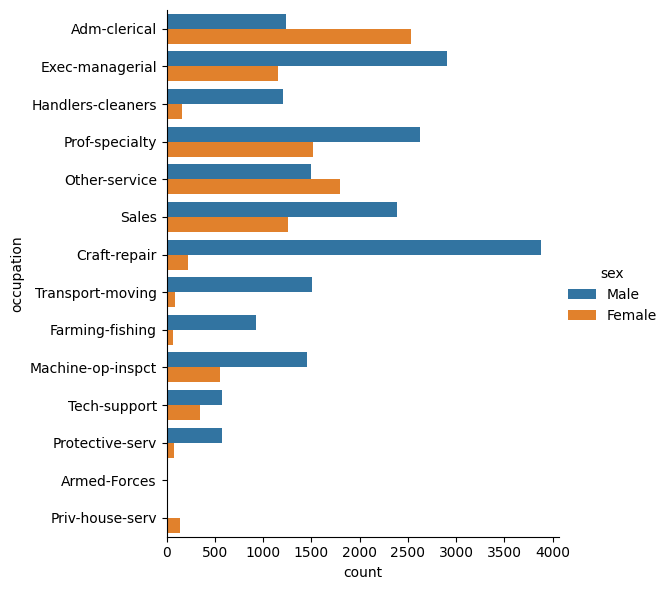

In [ ]:
import seaborn as sns

sns.catplot(
    df,
    y='occupation',
    hue='sex',
    kind='count',
    height=6
);

Or we can look at the counts, more specifcally, sorting by the `occupation`, then `sex`:

In [ ]:
df_subset = df[['occupation', 'sex']]
df_subset.value_counts().sort_index()

occupation         sex   
Adm-clerical       Female    2537
                   Male      1233
Armed-Forces       Male         9
Craft-repair       Female     222
                   Male      3877
Exec-managerial    Female    1159
                   Male      2907
Farming-fishing    Female      65
                   Male       929
Handlers-cleaners  Female     164
                   Male      1206
Machine-op-inspct  Female     550
                   Male      1452
Other-service      Female    1800
                   Male      1495
Priv-house-serv    Female     141
                   Male         8
Prof-specialty     Female    1515
                   Male      2625
Protective-serv    Female      76
                   Male       573
Sales              Female    1263
                   Male      2387
Tech-support       Female     348
                   Male       580
Transport-moving   Female      90
                   Male      1507
Name: count, dtype: int64

We might want to **look at percentages** rather than absolute counts, we we using cross-tabulation:

In [ ]:
# Create a contingency table to analyze the association between sex and occupation
contingency_table_2 = pd.crosstab(
    index=df['occupation'],
    columns=df['sex'],
    normalize='index'
)
contingency_table_2

sex,Female,Male
occupation,,
Adm-clerical,0.672944,0.327056
Armed-Forces,0.000000,1.000000
Craft-repair,0.054160,0.945840
Exec-managerial,0.285047,0.714953
Farming-fishing,0.065392,0.934608
Handlers-cleaners,0.119708,0.880292
Machine-op-inspct,0.274725,0.725275
Other-service,0.546282,0.453718
Priv-house-serv,0.946309,0.053691


Using a `heatmap` to add color and intensity makes it easier to read and compare:

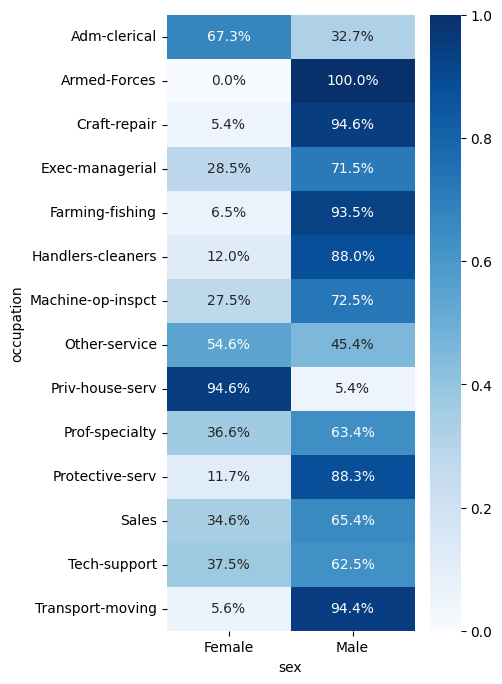

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 8))
sns.heatmap(data=contingency_table_2, annot=True, cmap="Blues", fmt=".1%");

### Step 1: Chi-square Test ($\chi^2$)

- The **Chi-squared test** is used to test for **association between two categorical variables**.
- However, it doesn't quantify how strong this association is.

Moreover, the test needs the unnormalized contingency table:

In [ ]:
# Create a contingency table to analyze the association between sex and occupation
contingency_table_2_unnormalized = pd.crosstab(
    index=df['occupation'],
    columns=df['sex'],
)
contingency_table_2_unnormalized

sex,Female,Male
occupation,,
Adm-clerical,2537,1233
Armed-Forces,0,9
Craft-repair,222,3877
Exec-managerial,1159,2907
Farming-fishing,65,929
Handlers-cleaners,164,1206
Machine-op-inspct,550,1452
Other-service,1800,1495
Priv-house-serv,141,8


#### Caveat: `< 5`

Drop rows where either `'Female'` or `'Male'` count is below `5`, as this **would cause over estimation of the relationship**:

In [ ]:
contingency_table_filtered = contingency_table_2_unnormalized[
    (contingency_table_2_unnormalized['Female'] >= 5) & (contingency_table_2_unnormalized['Male'] >= 5)
]
contingency_table_filtered

sex,Female,Male
occupation,,
Adm-clerical,2537,1233
Craft-repair,222,3877
Exec-managerial,1159,2907
Farming-fishing,65,929
Handlers-cleaners,164,1206
Machine-op-inspct,550,1452
Other-service,1800,1495
Priv-house-serv,141,8
Prof-specialty,1515,2625


Now let's apply the test: 

In [ ]:
from scipy.stats import chi2_contingency

# significance level
alpha = 0.05

# Run the Chi-Square Test
chi2_stat, p_value, dof, expected_frequencies = chi2_contingency(contingency_table_filtered)

print("\n--- Chi-Square Test Results ---")
print(f"P-value: {p_value:.2e}")  # Scientific notation is useful here
print("significant!" if p_value <= alpha else "not enough evidence")


--- Chi-Square Test Results ---
P-value: 0.00e+00
significant!


Always check the p-value of your Chi-square test first. If the p-value is not significant (usually $p > 0.05$), the association is likely due to chance, and interpreting Cramér's V becomes moot. In our case, the $p < 0.05$ and hence we proceed..

We do not care about the `chi2_stat` and `expected_frequencies`, but, we will need the **Degrees of Freedom** (`dof = min(n_rows, n_cols)`) in interpreting Cramer's V test result. 

### Step 2: Calculate Cramer's V

In [ ]:
from scipy.stats.contingency import association

# 2. Calculate Cramér's V
cramers_v = association(
    observed=contingency_table_filtered,
    method='cramer',
    correction=True
)

print(f"Cramér's V: {cramers_v:.2f}")

Cramér's V: 0.43


## Step 3: Interpreting the results

Cramér's V ranges from **0 to 1**. It does not indicate direction (since categorical data has no inherent order), only magnitude.

- **0**: No association between the variables.
- **1**: Perfect association (knowing the value of one variable allows you to perfectly predict the other).

Cohen (1988) provided general benchmarks for what constitutes a "small," "medium," or "large" effect, and can be generalized in the following snippet of code:

In [ ]:
import numpy as np

def interpret_cramers_v(v: float, dof: int) -> str:
    benchmarks = {
        "Small": 0.1 / np.sqrt(dof),
        "Medium": 0.3 / np.sqrt(dof),
        "Large": 0.5 / np.sqrt(dof)
    }
    
    if v < benchmarks["Small"]:
        return "Negligible"
    elif v < benchmarks["Medium"]:
        return "Small"
    elif v < benchmarks["Large"]:
        return "Medium"
    else:
        return "Large"

In [ ]:
print(f"Degrees of Freedom: {dof}")
print("Effect size:", interpret_cramers_v(cramers_v, dof))

Degrees of Freedom: 12
Effect size: Large
